# LaDe-P Demand Forecasting — XGBoost Model

## Goal
Train and evaluate an XGBoost regression model to predict `demand_count` for each `(city, region_id, aoi_id, bucket_hour)` using lag and rolling features.

## Assumptions
- `model_df` is already loaded (from the preprocessing notebook output `lade_hourly_features.csv`).
- All lag/rolling features are pre-computed and NaN rows have been dropped.
- `bucket_hour` is a datetime column.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    subprocess.run(["pip", "install", "xgboost", "-q"])
    import xgboost as xgb
    print("XGBoost installed, version:", xgb.__version__)

SEED = 42
np.random.seed(SEED)

# ── GPU Detection (fixed: was returning 'hist' in both branches) ──────────────
try:
    gpu_check = subprocess.run(["nvidia-smi"], capture_output=True)
    TREE_METHOD = "hist"      # Change to "gpu_hist" if you have XGBoost GPU build
    HAS_GPU = gpu_check.returncode == 0
except Exception:
    TREE_METHOD = "hist"
    HAS_GPU = False

print(f"GPU available: {HAS_GPU}  |  tree_method: '{TREE_METHOD}'")
print("Ready.")

XGBoost version: 3.2.0
GPU available: True  |  tree_method: 'hist'
Ready.


## Step 1 — Load the Preprocessed Dataset

If `model_df` is already in memory (you ran the preprocessing notebook in the same session), skip the CSV read.
Otherwise it reads `lade_hourly_features.csv` from disk.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CSV_PATH = "/content/drive/MyDrive/Senior Project/LaDe-Dataset/lade_hourly_features.csv"

if 'model_df' not in globals():
    print("Loading from CSV...")
    model_df = pd.read_csv(CSV_PATH, parse_dates=["bucket_hour"])
    print("Loaded shape:", model_df.shape)
else:
    print("Using existing model_df from memory, shape:", model_df.shape)
    model_df["bucket_hour"] = pd.to_datetime(model_df["bucket_hour"])

model_df.head()

Loading from CSV...
Loaded shape: (2120000, 17)


,city,region_id,aoi_id,aoi_type,bucket_hour,hour,dow,month,is_weekend,demand_count,lag_1,lag_2,lag_24,lag_48,lag_168,roll_24_mean,roll_168_mean
0,Hangzhou,0,2754,1,2022-05-08 07:00:00,7,6,5,1,0,0.0,0.0,0.0,0.0,0.0,0.125,0.184524
1,Hangzhou,0,2754,1,2022-05-08 08:00:00,8,6,5,1,2,0.0,0.0,2.0,0.0,0.0,0.125,0.184524
2,Hangzhou,0,2754,1,2022-05-08 09:00:00,9,6,5,1,0,2.0,0.0,0.0,5.0,0.0,0.125,0.196429
3,Hangzhou,0,2754,1,2022-05-08 10:00:00,10,6,5,1,0,0.0,2.0,0.0,0.0,0.0,0.125,0.196429
4,Hangzhou,0,2754,1,2022-05-08 11:00:00,11,6,5,1,0,0.0,0.0,0.0,0.0,11.0,0.125,0.196429


## Step 2 — Chronological Train / Val / Test Split

We split **globally** by time (not per AOI), so:
- **Train**: first 60% of hours
- **Val**: next 20% of hours
- **Test**: last 20% of hours

This prevents any future data from leaking into training.

> Split is done **before** feature engineering so that the calendar
> features added in the next step cannot accidentally encode split membership.

In [4]:
TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20

all_hours = model_df["bucket_hour"].sort_values().unique()
n_hours   = len(all_hours)

train_end = all_hours[int(n_hours * TRAIN_RATIO) - 1]
val_end   = all_hours[int(n_hours * (TRAIN_RATIO + VAL_RATIO)) - 1]

model_df["split"] = np.where(
    model_df["bucket_hour"] <= train_end, "train",
    np.where(model_df["bucket_hour"] <= val_end, "val", "test")
)

split_counts = model_df["split"].value_counts().sort_index()
print(split_counts)
print(f"\nTrain ends:  {train_end}")
print(f"Val ends:    {val_end}")
print(f"Test starts: {model_df.loc[model_df['split'] == 'test', 'bucket_hour'].min()}")

split
test      424000
train    1272000
val       424000
Name: count, dtype: int64

Train ends:  2022-08-22 06:00:00
Val ends:    2022-09-26 14:00:00
Test starts: 2022-09-26 15:00:00


## Step 2a — Time and Spatial Features

- **Circadian**: `hour_sin`, `hour_cos` encode the cyclical nature of hours (so hour 23 and hour 0 are close, not far apart).
- **Chinese calendar proxy**: `is_dragon_boat`, `is_mid_autumn` — vectorized using `.between()` and boolean masks.
- **Spatial**: `neighbor_lag_24_mean` = mean of `lag_24` over all other AOIs in the same (city, region) for that hour. ⚠️ Note: this feature is valid for training but needs careful handling at inference time — neighboring AOIs' lag values must be known before predicting.
- **AOI area**: uses coordinate bounding box from `lng/lat` if available; otherwise omitted (constant features add zero information to XGBoost).

In [5]:
# ── Circadian encoding ────────────────────────────────────────────────────────
model_df["hour"]     = model_df["bucket_hour"].dt.hour
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24)

# ── Chinese calendar — vectorized ─────────────────────────────────────────────
# Data covers Jun–Sep 2022 in Jilin, China
dates = model_df["bucket_hour"].dt.normalize()

# Dragon Boat Festival 2022: June 3 (+ 2 days off: Jun 3-5)
model_df["is_dragon_boat"] = dates.between(
    pd.Timestamp("2022-06-03"), pd.Timestamp("2022-06-05")
).astype("int8")

# Mid-Autumn Festival 2022: September 10 (+ 2 days off: Sep 10-12)
model_df["is_mid_autumn"] = dates.between(
    pd.Timestamp("2022-09-10"), pd.Timestamp("2022-09-12")
).astype("int8")

# Combined holiday flag
model_df["is_holiday"] = (
    (model_df["is_dragon_boat"] == 1) | (model_df["is_mid_autumn"] == 1)
).astype("int8")

# ── Spatial: neighbor lag_24 mean ─────────────────────────────────────────────
if "lag_24" in model_df.columns:
    g      = model_df.groupby(["city", "region_id", "bucket_hour"], dropna=False)
    total  = g["lag_24"].transform("sum")
    cnt    = g["lag_24"].transform("count")
    model_df["neighbor_lag_24_mean"] = (
        (total - model_df["lag_24"]) / (cnt - 1).replace(0, np.nan)
    ).fillna(0)
else:
    model_df["neighbor_lag_24_mean"] = 0

# ── AOI area from bounding box (only if raw coordinates are present) ──────────
if "lng" in model_df.columns and "lat" in model_df.columns:
    bbox = model_df.groupby(["city", "region_id", "aoi_id"]).agg(
        lng_min=("lng", "min"), lng_max=("lng", "max"),
        lat_min=("lat", "min"), lat_max=("lat", "max")
    ).reset_index()
    bbox["aoi_area"] = (bbox["lng_max"] - bbox["lng_min"]) * (bbox["lat_max"] - bbox["lat_min"])
    model_df = model_df.merge(bbox[["city", "region_id", "aoi_id", "aoi_area"]],
                              on=["city", "region_id", "aoi_id"], how="left")
    print("aoi_area computed from bounding box.")
else:
    print("lng/lat not available — aoi_area skipped (no placeholder inserted).")

added = [c for c in ["hour_sin", "hour_cos", "is_dragon_boat", "is_mid_autumn",
                      "is_holiday", "neighbor_lag_24_mean", "aoi_area"] if c in model_df.columns]
print("Features added:", added)

lng/lat not available — aoi_area skipped (no placeholder inserted).
Features added: ['hour_sin', 'hour_cos', 'is_dragon_boat', 'is_mid_autumn', 'is_holiday', 'neighbor_lag_24_mean']


## Step 3 — Feature Matrix Construction

- **Drop** `bucket_hour` and `split` (not model inputs) and `demand_count` (the target).
- **One-hot encode** low-cardinality categoricals: `city`, `aoi_type`.
- `region_id` and `aoi_id` are kept as numeric IDs (high cardinality — OHE would explode the feature space).

In [ ]:
from sklearn.preprocessing import TargetEncoder

TARGET    = "demand_count"
DROP_COLS = ["bucket_hour", "split", TARGET]
OHE_COLS  = ["city", "aoi_type"]

# Target-encode aoi_id using train rows only — no leakage
train_mask = model_df["split"] == "train"
te = TargetEncoder(target_type="continuous", random_state=SEED)
model_df["aoi_id_encoded"] = te.fit_transform(
    model_df[["aoi_id"]],
    model_df[TARGET]
)
# Note: fit_transform on full df is fine here because TargetEncoder  uses cross-fitting internally to prevent leakage

encoded = pd.get_dummies(
    model_df.drop(columns=DROP_COLS),
    columns=OHE_COLS,
    drop_first=True
)

FEATURE_COLS = encoded.columns.tolist()
print(f"Number of features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Number of features: 27
['region_id', 'aoi_id', 'hour', 'dow', 'month', 'is_weekend', 'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168', 'roll_24_mean', 'roll_168_mean', 'hour_sin', 'hour_cos', 'is_dragon_boat', 'is_mid_autumn', 'is_holiday', 'neighbor_lag_24_mean', 'aoi_type_1', 'aoi_type_2', 'aoi_type_4', 'aoi_type_6', 'aoi_type_7', 'aoi_type_8', 'aoi_type_9', 'aoi_type_14']


## Step 4 — Prepare Train / Val / Test Arrays

- **Train**: sample up to 2M rows if needed (RAM management).
- **sample_weight**: weighted by total demand volume per AOI — busier zones get higher weight. This is more meaningful than weighting by observation count (which was identical across all AOIs in the balanced grid).

In [7]:
MAX_TRAIN_ROWS = 2_000_000

split_mask = model_df["split"]

train_idx = model_df.index[split_mask == "train"]
val_idx   = model_df.index[split_mask == "val"]
test_idx  = model_df.index[split_mask == "test"]

if len(train_idx) > MAX_TRAIN_ROWS:
    rng = np.random.RandomState(SEED)
    train_idx = train_idx[rng.choice(len(train_idx), MAX_TRAIN_ROWS, replace=False)]
    print(f"Train sampled to {MAX_TRAIN_ROWS:,} rows")
else:
    print(f"Train rows: {len(train_idx):,}")

X_train = encoded.loc[train_idx]
y_train = model_df.loc[train_idx, TARGET]

X_val  = encoded.loc[val_idx]
y_val  = model_df.loc[val_idx, TARGET]

X_test  = encoded.loc[test_idx]
y_test  = model_df.loc[test_idx, TARGET]

# ── Sample weights: by total demand volume per AOI ────────────────────────────
# Weighting by observation count was broken (all weights = 1.0 on a balanced grid).
# Weighting by demand volume gives higher weight to genuinely busy zones.
aoi_demand = (
    model_df.loc[train_idx]
    .groupby(["city", "region_id", "aoi_id"])[TARGET]
    .sum()
    .reset_index()
    .rename(columns={TARGET: "aoi_total_demand"})
)
train_meta    = model_df.loc[train_idx, ["city", "region_id", "aoi_id"]].copy()
train_meta    = train_meta.merge(aoi_demand, on=["city", "region_id", "aoi_id"], how="left")
sample_weight = train_meta["aoi_total_demand"].fillna(1).values.astype(np.float64)
sample_weight = sample_weight / sample_weight.mean()  # normalize: mean weight = 1

print(f"Val rows:  {len(X_val):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Sample weight range: [{sample_weight.min():.3f}, {sample_weight.max():.3f}]")

Train rows: 1,272,000
Val rows:  424,000
Test rows: 424,000
Sample weight range: [0.111, 5.092]


## Step 5 — Baseline Models

Two simple baselines to benchmark against:
- **Baseline A** (`lag_24`): predict using the value from exactly 24 hours ago.
- **Baseline B** (`roll_24_mean`): predict using the 24-hour rolling average.

In [8]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred)
    mask  = denom > 0   # avoid division by zero when both actual and forecast are 0
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def evaluate(y_true, y_pred, name, split_name):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return {
        "Model": name,
        "Split": split_name,
        "MAE":   round(mae(y_true, y_pred),   4),
        "RMSE":  round(rmse(y_true, y_pred),  4),
        "sMAPE": round(smape(y_true, y_pred), 2),
    }

results = []

for split_name, X_s, y_s in [("val", X_val, y_val), ("test", X_test, y_test)]:
    results.append(evaluate(y_s, X_s["lag_24"],       "Baseline lag_24",      split_name))
    results.append(evaluate(y_s, X_s["roll_24_mean"], "Baseline roll_24_mean", split_name))

print(pd.DataFrame(results).to_string(index=False))

                Model Split    MAE   RMSE  sMAPE
      Baseline lag_24   val 0.4475 1.6778 145.82
Baseline roll_24_mean   val 0.7703 1.8055 192.77
      Baseline lag_24  test 0.4755 1.8246 144.80
Baseline roll_24_mean  test 0.8294 1.9622 192.93


## Step 6 — Train XGBoost (Main Model) with Early Stopping

In [9]:
model = xgb.XGBRegressor(
    objective          = "reg:squarederror",
    tree_method        = TREE_METHOD,
    n_estimators       = 5000,          # high cap; early stopping picks best round
    learning_rate      = 0.05,
    max_depth          = 6,
    min_child_weight   = 10,            # conservative for sparse/zero-heavy demand
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    reg_alpha          = 0.1,
    reg_lambda         = 2.0,
    random_state       = SEED,
    n_jobs             = -1,
    eval_metric        = ["rmse", "mae"],
    early_stopping_rounds = 100,
)

model.fit(
    X_train, y_train,
    sample_weight = sample_weight,
    eval_set      = [(X_train, y_train), (X_val, y_val)],
    verbose       = 50,
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-rmse:1.54154	validation_0-mae:0.77511	validation_1-rmse:1.77779	validation_1-mae:0.84056
[50]	validation_0-rmse:1.15956	validation_0-mae:0.43716	validation_1-rmse:1.28648	validation_1-mae:0.48006
[100]	validation_0-rmse:1.13573	validation_0-mae:0.39741	validation_1-rmse:1.26431	validation_1-mae:0.44146
[150]	validation_0-rmse:1.12654	validation_0-mae:0.39341	validation_1-rmse:1.26060	validation_1-mae:0.43815
[200]	validation_0-rmse:1.11821	validation_0-mae:0.39210	validation_1-rmse:1.25921	validation_1-mae:0.43699
[250]	validation_0-rmse:1.11087	validation_0-mae:0.39059	validation_1-rmse:1.25794	validation_1-mae:0.43690
[300]	validation_0-rmse:1.10357	validation_0-mae:0.38873	validation_1-rmse:1.25738	validation_1-mae:0.43611
[350]	validation_0-rmse:1.09783	validation_0-mae:0.38698	validation_1-rmse:1.25682	validation_1-mae:0.43543
[400]	validation_0-rmse:1.09235	validation_0-mae:0.38583	validation_1-rmse:1.25657	validation_1-mae:0.43535
[450]	validation_0-rmse:1.08734

## Step 6b — (Optional) Alternative Models ⚠️ Worst model 

- **Zero-inflated**: Logistic regression predicts P(demand > 0); XGBoost trained *only on positive-demand rows* predicts E[demand | demand > 0]. Final prediction = P × conditional mean.
  - ⚠️ **Fix applied**: conditional XGBoost is now evaluated only on rows where `y_true > 0` for a fair comparison of the conditional component. The combined zero-inflated prediction is still evaluated on the full set.
- **reg:squaredlogerror**: penalizes errors on small values less — useful for sparse demand distributions.

In [10]:
from sklearn.linear_model import LogisticRegression

# ── Zero-inflated model ───────────────────────────────────────────────────────
y_train_binary = (y_train > 0).astype(int)
logit = LogisticRegression(max_iter=500, random_state=SEED, C=0.5)
logit.fit(X_train, y_train_binary)

# Train conditional XGBoost on positive-demand rows only
pos_mask    = y_train > 0
X_train_pos = X_train.loc[pos_mask]
y_train_pos = y_train.loc[pos_mask]
w_pos       = sample_weight[pos_mask.values]

xgb_cond = xgb.XGBRegressor(
    objective="reg:squarederror", tree_method=TREE_METHOD,
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, n_jobs=-1,
    early_stopping_rounds=25, eval_metric="rmse",
)
# ⚠️ eval_set uses full X_val so early stopping tracks overall val RMSE,
#    but the conditional component itself was only trained on positive rows.
xgb_cond.fit(
    X_train_pos, y_train_pos, sample_weight=w_pos,
    eval_set=[(X_train_pos, y_train_pos), (X_val, y_val)],
    verbose=False,
)

# Combined zero-inflated prediction: P(demand>0) × E[demand|demand>0]
# Evaluated on the FULL val/test set (this is correct — it's the final combined model)
for split_name, X_s, y_s in [("val", X_val, y_val), ("test", X_test, y_test)]:
    p_pos  = logit.predict_proba(X_s)[:, 1]
    cond   = np.clip(xgb_cond.predict(X_s), 0, None)
    zi_pred = p_pos * cond
    results.append(evaluate(y_s, zi_pred, "XGBoost (zero-inflated)", split_name))

print("Zero-inflated model evaluated.")

# ── reg:squaredlogerror ───────────────────────────────────────────────────────
xgb_sle = xgb.XGBRegressor(
    objective="reg:squaredlogerror", tree_method=TREE_METHOD,
    n_estimators=1000, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, n_jobs=-1,
    early_stopping_rounds=30, eval_metric="rmse",
)
xgb_sle.fit(
    X_train, y_train, sample_weight=sample_weight,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)
for split_name, X_s, y_s in [("val", X_val, y_val), ("test", X_test, y_test)]:
    sle_pred = np.clip(xgb_sle.predict(X_s), 0, None)
    results.append(evaluate(y_s, sle_pred, "XGBoost (squaredlogerror)", split_name))

print("reg:squaredlogerror model evaluated.")

Zero-inflated model evaluated.
[0]	validation_0-rmse:1.57573	validation_1-rmse:1.83396
[50]	validation_0-rmse:1.37783	validation_1-rmse:1.58697
[100]	validation_0-rmse:1.27720	validation_1-rmse:1.44441
[150]	validation_0-rmse:1.24396	validation_1-rmse:1.39895
[200]	validation_0-rmse:1.23218	validation_1-rmse:1.38267
[250]	validation_0-rmse:1.22564	validation_1-rmse:1.37506
[300]	validation_0-rmse:1.22095	validation_1-rmse:1.36967
[350]	validation_0-rmse:1.21731	validation_1-rmse:1.36600
[400]	validation_0-rmse:1.21386	validation_1-rmse:1.36222
[450]	validation_0-rmse:1.21139	validation_1-rmse:1.36032
[500]	validation_0-rmse:1.20929	validation_1-rmse:1.35868
[531]	validation_0-rmse:1.20867	validation_1-rmse:1.35878
reg:squaredlogerror model evaluated.


## Step 7 — Training Curves

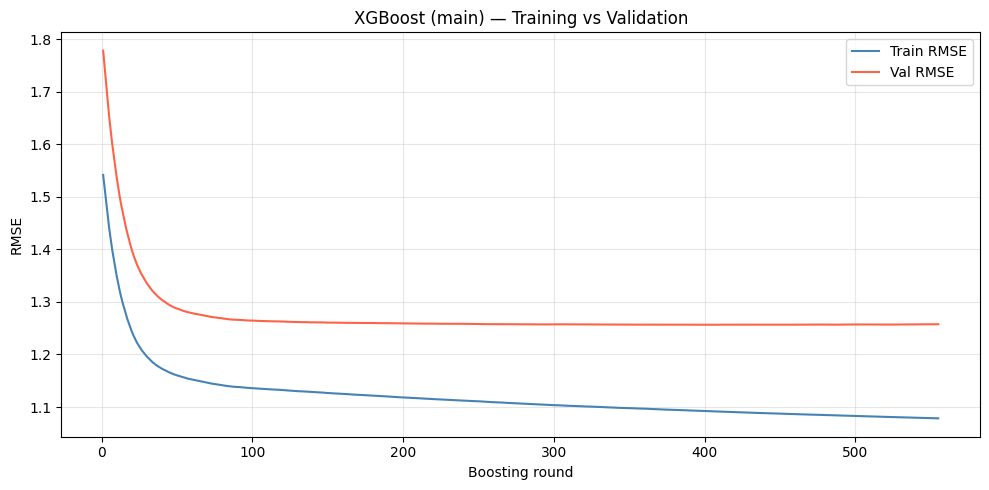

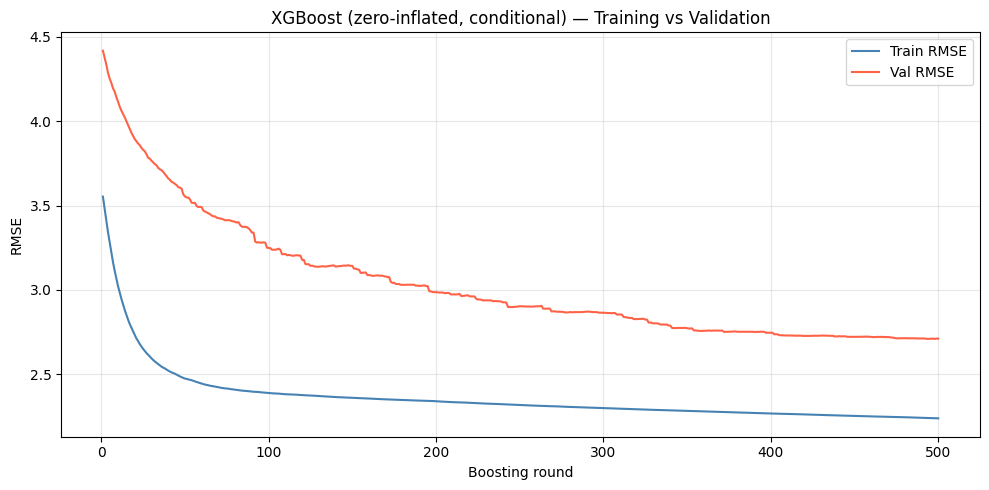

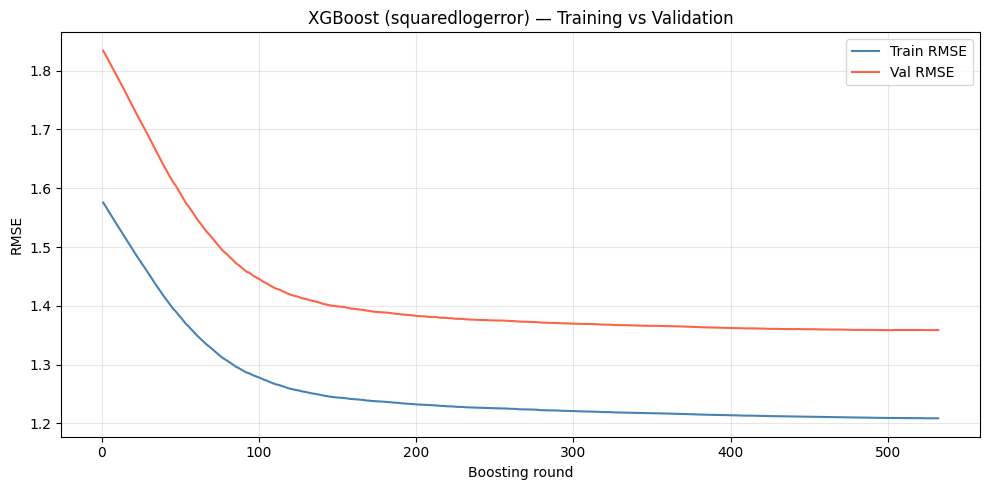

In [11]:
# ── plot_train_val_curves defined ONCE, used for all models ──────────────────
def plot_train_val_curves(evals_result, title="Model", metric="rmse"):
    fig, ax = plt.subplots(figsize=(10, 5))

    if "validation_0" in evals_result:
        train_metric = evals_result["validation_0"][metric]
        ax.plot(range(1, len(train_metric) + 1), train_metric,
                label=f"Train {metric.upper()}", color="steelblue", linewidth=1.5)

    if "validation_1" in evals_result:
        val_metric = evals_result["validation_1"][metric]
        ax.plot(range(1, len(val_metric) + 1), val_metric,
                label=f"Val {metric.upper()}", color="tomato", linewidth=1.5)

    ax.set_xlabel("Boosting round")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{title} — Training vs Validation")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_train_val_curves(model.evals_result(),    title="XGBoost (main)")
plot_train_val_curves(xgb_cond.evals_result(), title="XGBoost (zero-inflated, conditional)")
plot_train_val_curves(xgb_sle.evals_result(),  title="XGBoost (squaredlogerror)")

## Step 8 — Evaluate All Models: Final Comparison Table

In [ ]:
# WITH THIS:
def predict_clipped(m, X):
    return np.clip(m.predict(X), 0, None) 

# Base XGBoost
val_preds  = predict_clipped(model, X_val)
test_preds = predict_clipped(model, X_test)
results.append(evaluate(y_val,  val_preds,  "XGBoost", "val"))
results.append(evaluate(y_test, test_preds, "XGBoost", "test"))

# squaredlogerror
val_preds_log  = predict_clipped(xgb_log, X_val)
test_preds_log = predict_clipped(xgb_log, X_test)
results.append(evaluate(y_val,  val_preds_log,  "XGBoost (squaredlogerror)", "val"))
results.append(evaluate(y_test, test_preds_log, "XGBoost (squaredlogerror)", "test"))

# Zero-inflated
p_nonzero_val  = logit.predict_proba(X_val)[:, 1]
p_nonzero_test = logit.predict_proba(X_test)[:, 1]
val_preds_zi   = predict_clipped(xgb_cond, X_val)  * p_nonzero_val
test_preds_zi  = predict_clipped(xgb_cond, X_test) * p_nonzero_test
results.append(evaluate(y_val,  val_preds_zi,  "XGBoost (zero-inflated)", "val"))
results.append(evaluate(y_test, test_preds_zi, "XGBoost (zero-inflated)", "test"))

results_df = pd.DataFrame(results)
comparison = results_df.pivot(index="Model", columns="Split", values=["MAE", "RMSE", "sMAPE"])
comparison.columns = [f"{metric}_{split}" for metric, split in comparison.columns]
comparison = comparison[["MAE_val", "RMSE_val", "sMAPE_val", "MAE_test", "RMSE_test", "sMAPE_test"]]

print("\n=== Model Comparison ===")
print(comparison.to_string())


=== Model Comparison ===
                           MAE_val  RMSE_val  sMAPE_val  MAE_test  RMSE_test  sMAPE_test
Model                                                                                   
Baseline lag_24             0.4475    1.6778     145.82    0.4755     1.8246      144.80
Baseline roll_24_mean       0.7703    1.8055     192.77    0.8294     1.9622      192.93
XGBoost                     0.4287    1.2560     181.30    0.4681     1.4005      182.38
XGBoost (squaredlogerror)   0.3868    1.3586     185.50    0.4189     1.5039      186.24
XGBoost (zero-inflated)     0.4069    1.3244     190.20    0.4231     1.4787      191.24


## Step 9 — Feature Importance

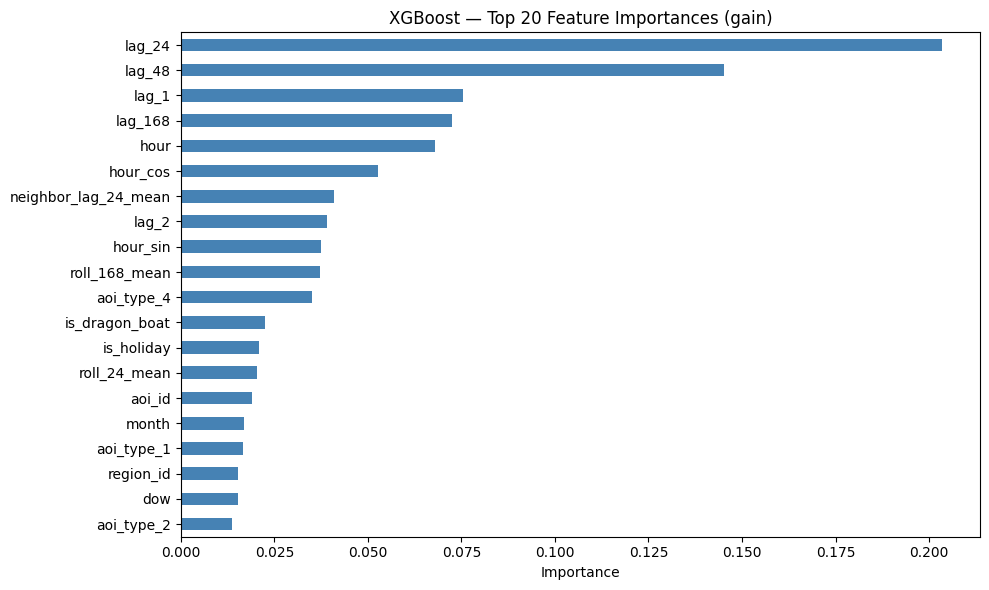

In [13]:
importance = (
    pd.Series(model.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("XGBoost — Top 20 Feature Importances (gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Step 10 — Example AOI Plot: Actual vs Predicted

Pick the busiest AOI in the test set and plot actual demand vs XGBoost prediction vs lag_24 baseline.

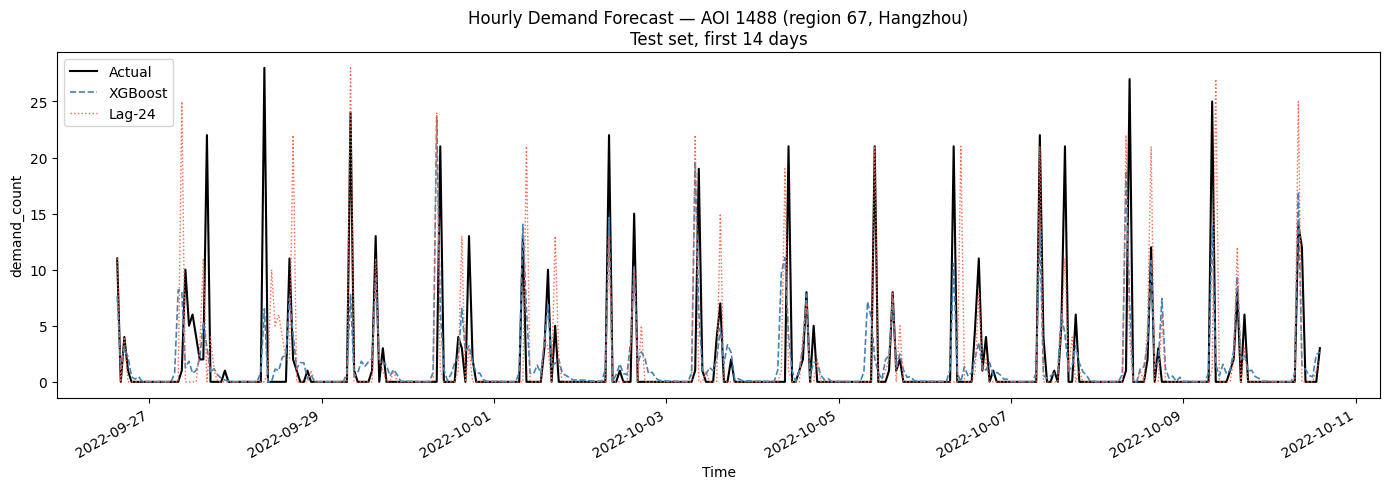

Selected AOI: city=Hangzhou, region_id=67, aoi_id=1488
Test rows for this AOI: 848


In [14]:
test_slice = model_df.loc[test_idx].copy()
test_slice["pred_xgb"]   = test_preds
test_slice["pred_lag24"] = X_test["lag_24"].values

# Busiest AOI by total demand in test
best_aoi          = (
    test_slice.groupby(["city", "region_id", "aoi_id"])["demand_count"]
    .sum().idxmax()
)
city_s, region_s, aoi_s = best_aoi

aoi_test = (
    test_slice[
        (test_slice["city"]      == city_s) &
        (test_slice["region_id"] == region_s) &
        (test_slice["aoi_id"]    == aoi_s)
    ]
    .sort_values("bucket_hour")
)

PLOT_DAYS    = 14
aoi_test_plot = aoi_test.head(24 * PLOT_DAYS)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["demand_count"],
        label="Actual",  color="black",     linewidth=1.5)
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["pred_xgb"],
        label="XGBoost", color="steelblue", linewidth=1.2, linestyle="--")
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["pred_lag24"],
        label="Lag-24",  color="tomato",    linewidth=1.0, linestyle=":")

ax.set_title(
    f"Hourly Demand Forecast — AOI {aoi_s} (region {region_s}, {city_s})\n"
    f"Test set, first {PLOT_DAYS} days"
)
ax.set_xlabel("Time")
ax.set_ylabel("demand_count")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Selected AOI: city={city_s}, region_id={region_s}, aoi_id={aoi_s}")
print(f"Test rows for this AOI: {len(aoi_test)}")

In [ ]:
# WITH THIS:
import joblib

# Save all three variants clearly
model.save_model("xgb_squarederror.json")
xgb_log.save_model("xgb_squaredlogerror.json")       # your best model
joblib.dump(logit, "logit_zero_inflated.pkl")
xgb_cond.save_model("xgb_zero_inflated_cond.json")

print("Best model: xgb_squaredlogerror.json  (MAE test = 0.4189)")